In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("movie_votes.csv")

df.head()

,Unnamed: 0,title,year,runtime,rating,votes,genre,text
0,0,The Shawshank Redemption,(1994),142 mins.,9.3,"1,432,740","[u'Crime', u'Drama']",Two imprisoned men bond over a number of years...
1,1,The Dark Knight,(2008),152 mins.,9.0,"1,403,109","[u'Action', u'Crime', u'Drama']",When the menace known as the Joker wreaks havo...
2,2,Inception,(2010),148 mins.,8.8,"1,202,244","[u'Action', u'Mystery', u'Sci-Fi', u'Thriller']",A thief who steals corporate secrets through u...
3,3,Fight Club,(1999),139 mins.,8.9,"1,117,474",[u'Drama'],An insomniac office worker looking for a way t...
4,4,Pulp Fiction,(1994),154 mins.,8.9,"1,111,865","[u'Crime', u'Drama']","The lives of two mob hit men, a boxer, a gangs..."


In [3]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(6510, 8)
<class 'pandas.DataFrame'>
RangeIndex: 6510 entries, 0 to 6509
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6510 non-null   int64  
 1   title       6510 non-null   str    
 2   year        6510 non-null   str    
 3   runtime     6489 non-null   str    
 4   rating      6510 non-null   float64
 5   votes       6510 non-null   str    
 6   genre       6509 non-null   str    
 7   text        6509 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 1.7 MB
None
        Unnamed: 0       rating
count  6510.000000  6510.000000
mean   3254.500000     6.833379
std    1879.419458     1.110977
min       0.000000     1.600000
25%    1627.250000     6.200000
50%    3254.500000     6.900000
75%    4881.750000     7.600000
max    6509.000000     9.900000
Unnamed: 0     0
title          0
year           0
runtime       21
rating         0
votes          0
genre          1
text           

In [5]:
# Numeric columns → median
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))

# Categorical columns → mode
cat_cols = df.select_dtypes(include=["object", "string"]).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

In [7]:
df[col] = le.fit_transform(df[col])

In [8]:
X = df.drop("votes", axis=1)   # change if your target is different
y = df["votes"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

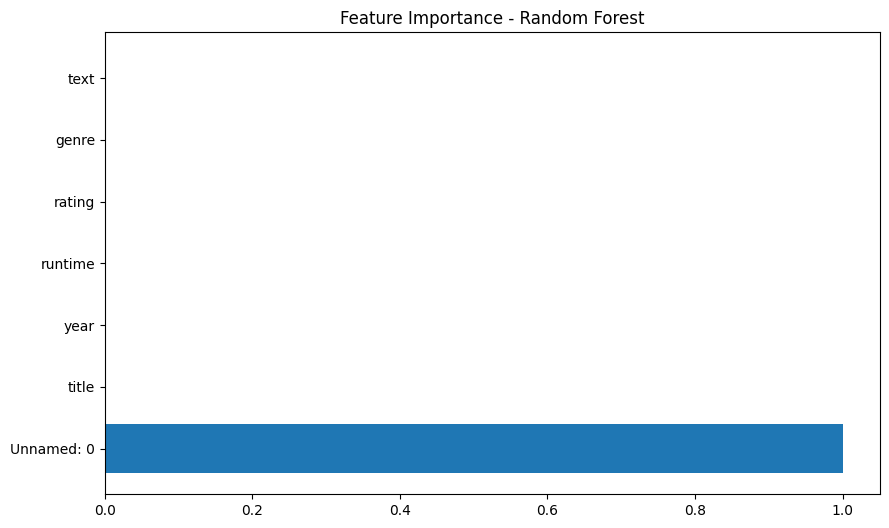

In [12]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()